# small-indel-only new-peak genes across the 20 climate axes — LFMM, raw, clq0.9 tiling

Standalone dot grid, lifted out of `raw_manhattan_snp_vs_smallindel_lfmm_tile.ipynb` (which is
slow — it renders 20 dense mirror Manhattans first). Same `newpk` definition: a clq0.9
**tiling** block whose LEAD (min-p) smallindel record clears per-class Bonferroni (0.05/n) while
its lead SNP record in the same block does **not** — SNP-absent blocks count as
SNP-not-significant, which is exactly the "what did small-indel find that SNPs missed"
question the project is asking. Per-record `wza_in_clq09_tile` LFMM p, gen9, MAF>0.05.

**Raw, uncalibrated p — no GIF correction** (see `gif_manhattan_snp_vs_smallindel_lfmm_tile.ipynb`
for the inflation-corrected view). Rows ordered by indel/SV size; right panel shows that size.

In [1]:
import os, sys
import numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
import lib
GEA = lib.GEA
WZAIN = f"{GEA}/phase1_replication/results/multiaxis/wza_in_clq09_tile"
AXES = [f"bio{i}" for i in range(1, 20)] + ["pc1"]
MODEL = "lfmm"
CLS = "smallindel"
plt.rcParams.update({"figure.dpi":110})

def block_spans_tiling(r2=0.9):
    """Tiling block spans: each block absorbs the preceding gap (matches reblock_blockdef.py)."""
    tag=f"clq{r2}"; rows=[]
    for ci in range(1,6):
        ch = f"Chr{ci}"
        g=pd.read_csv(f"{lib.CLQ_BLOCKS_DIR}/chr{ci}_{tag}_blocks_{tag}.tsv",sep="\t").sort_values("start_pos").reset_index(drop=True)
        ends = g.end_pos.to_numpy(np.int64)
        for i in range(len(g)):
            lo = 1 if i == 0 else int(ends[i-1]) + 1
            hi = int(ends[i]) if i < len(g)-1 else 10**9
            rows.append((f"{ch}_{i}", ch, lo, hi))
    return pd.DataFrame(rows,columns=["block","chrom","start","end"]).set_index("block")
SPANS=block_spans_tiling(); GENES=lib.load_genes()
def genes_on(block):
    if block not in SPANS.index: return []
    s=SPANS.loc[block]; gc=GENES[(GENES.chrom==s.chrom)&(GENES.end>=s.start)&(GENES.start<=s.end)]
    return list(gc.gene)
print("loaded:", len(SPANS), "tiling blocks,", len(GENES), "genes ; class =", CLS)

loaded: 58376 tiling blocks, 27206 genes ; class = smallindel


In [2]:
# --- recompute new peaks across all axes (no Manhattan rendering) ---
def load_raw(cls, axis):
    f = f"{WZAIN}/{MODEL}_{cls}_gen9_{axis}.csv"
    if not os.path.exists(f): return None
    d = pd.read_csv(f)
    d = d[d["MAF"] > 0.05].copy()
    d["nlp"] = -np.log10(d["pval"].clip(lower=1e-300))
    d["size"] = (d["alt_len"] - d["ref_len"]).abs()          # |indel/SV| length change, bp
    return d

def leads(d):
    d = d[d["block"].notna() & (d["block"] != "")]
    return d.loc[d.groupby("block")["nlp"].idxmax()]         # lead (min-p) record per block

def newpeaks(axis, cls):
    s, c = load_raw("snp", axis), load_raw(cls, axis)
    if s is None or c is None:
        return None
    bonf_s, bonf_c = -np.log10(0.05 / len(s)), -np.log10(0.05 / len(c))
    ls_, lc_ = leads(s), leads(c)
    m = lc_.merge(ls_[["block", "nlp"]], on="block", suffixes=("", "_snp"), how="left")
    m["nlp_snp"] = m["nlp_snp"].fillna(0.0)                  # SNP-absent block -> SNP not sig
    npk = m[(m["nlp"] > bonf_c) & (m["nlp_snp"] <= bonf_s)].copy()
    npk["genes"] = npk["block"].map(lambda b: ";".join(genes_on(b)))
    npk["axis"] = axis
    return npk[["block", "chrom", "pos", "size", "nlp", "nlp_snp", "genes", "axis"]]

all_newpk = []
for a in AXES:
    x = newpeaks(a, CLS)
    if x is None:
        print("missing", a); continue
    all_newpk.append(x)
    print(f"{a}: {len(x)} {CLS}-only new peaks ({(x.genes != '').sum()} gene-bearing)")
ALLPK = pd.concat(all_newpk, ignore_index=True) if all_newpk else pd.DataFrame()
print("total (block,axis) new peaks:", len(ALLPK))

bio1: 124 smallindel-only new peaks (98 gene-bearing)


bio2: 2 smallindel-only new peaks (1 gene-bearing)


bio3: 36 smallindel-only new peaks (33 gene-bearing)


bio4: 24 smallindel-only new peaks (20 gene-bearing)


bio5: 18 smallindel-only new peaks (13 gene-bearing)


...

bio16: 0 smallindel-only new peaks (0 gene-bearing)


bio17: 15 smallindel-only new peaks (11 gene-bearing)


bio18: 8 smallindel-only new peaks (6 gene-bearing)


bio19: 0 smallindel-only new peaks (0 gene-bearing)


pc1: 51 smallindel-only new peaks (45 gene-bearing)
total (block,axis) new peaks: 876


In [3]:
# --- gene-level table: one row per (gene, axis), plus a representative (strongest) row per gene ---
GENE = ALLPK.assign(gene=ALLPK["genes"].str.split(";")).explode("gene")
GENE = GENE[GENE["gene"].astype(bool)].copy()
GA = GENE.sort_values("nlp", ascending=False).drop_duplicates(["gene", "axis"])   # 1 row / (gene,axis)
nax = GA.groupby("gene")["axis"].nunique().rename("n_axes")
rep = (GA.sort_values("nlp", ascending=False).drop_duplicates("gene")             # strongest axis / gene
         .set_index("gene").join(nax))
print(f"{rep.shape[0]} unique gene-bearing {CLS}-only new-peak genes")

1255 unique gene-bearing smallindel-only new-peak genes


In [4]:
# --- annotate genes (TAIR GO + UniProt) — the mandated annotator ---
import importlib.util as _ilu
_annp = os.path.abspath(os.path.join(os.getcwd(), "..", "annotate_genes_tair_uniprot.py"))
_sp = _ilu.spec_from_file_location("ann_tu", _annp)
ann_tu = _ilu.module_from_spec(_sp); _sp.loader.exec_module(ann_tu)

A = ann_tu.annotate(sorted(rep.index.tolist()))
A = A.set_index("gene")
rep = rep.join(A[["symbol", "protein_name", "categories"]])
rep["categories"] = rep["categories"].fillna("")
rep["symbol"] = rep["symbol"].fillna("")
_outp = f"{lib.GEA}/phase1_replication/results/multiaxis/newpeak_dotgrid_genes_{CLS}_tile.csv"
rep.reset_index().to_csv(_outp, index=False)
print(f"wrote {_outp}")
print("category counts (a gene can carry several):")
print(rep["categories"].str.split(",").explode().replace("", pd.NA).dropna().value_counts().to_string())

annotating 1255 genes

-- TAIR GAF (GO Consortium) --


GAF cache: /global/scratch/projects/fc_moilab/tbellg/kmate/analysis/grenenet_gea/phase1_replication/results/cache/tair.gaf.gz (7.2 MB)


   GO for 927/1255 genes
-- UniProt REST pass 1: reviewed / Swiss-Prot (taxid 3702) --


  uniprot 40/1255 -> 25 mapped


  uniprot 80/1255 -> 47 mapped


...

  uniprot 560/601 -> 533 mapped


  uniprot 600/601 -> 570 mapped


  uniprot 601/601 -> 571 mapped


   UniProt total: 1225/1255 genes
-- mygene.info (kept for GO term NAMES + entrez) --


wrote /global/scratch/projects/fc_moilab/tbellg/kmate/analysis/grenenet_gea/phase1_replication/results/multiaxis/newpeak_dotgrid_genes_smallindel_tile.csv
category counts (a gene can carry several):
categories
defense        165
temperature     89
water           87
oxidative       67
flowering       45
calcium         34
light           30


/tmp/ipykernel_3557831/4261391412.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


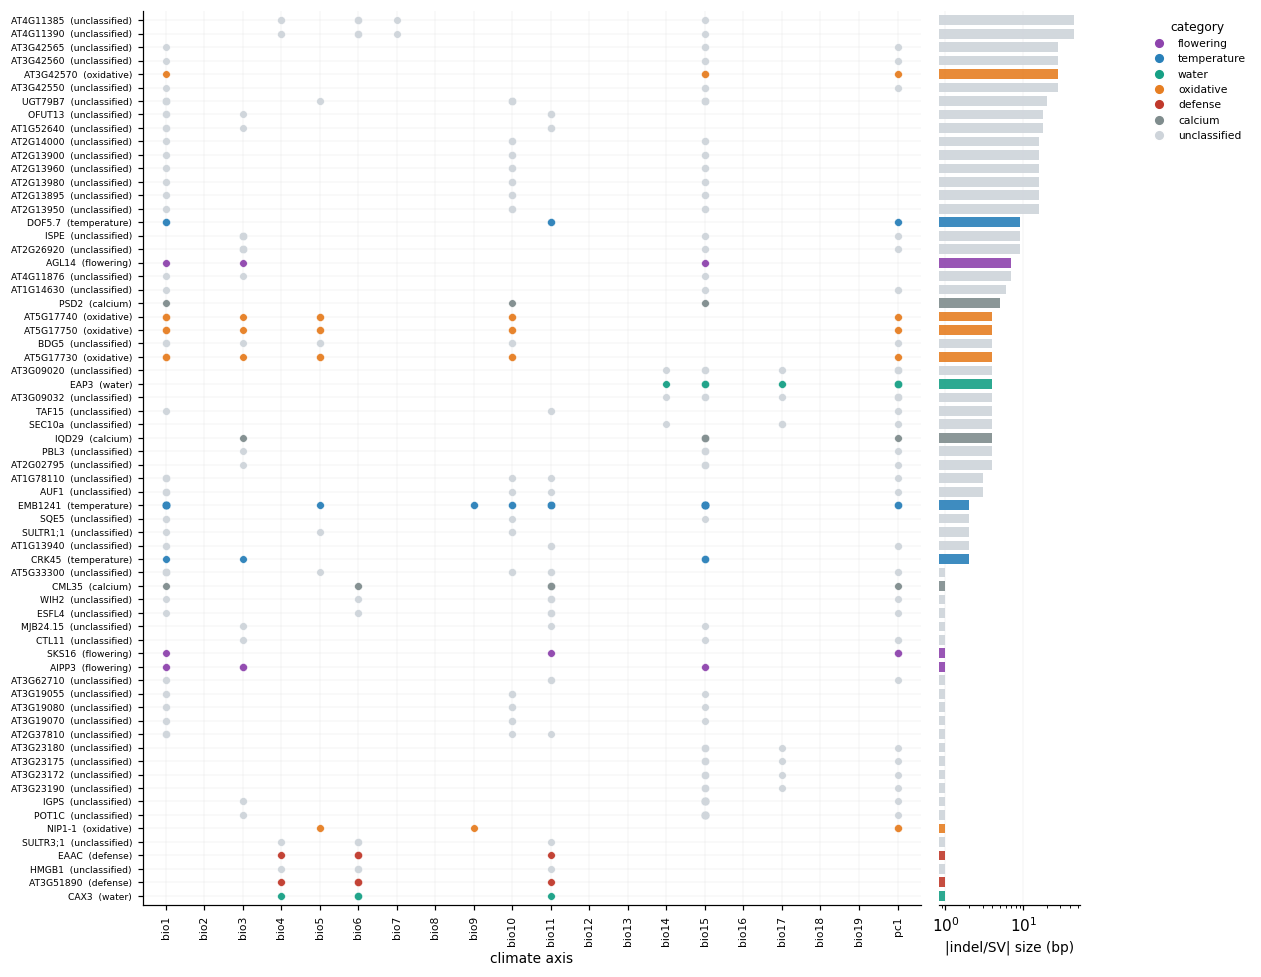

dot grid: 66 genes recurring on >=3 of 20 axes; 1189 lower-recurrence genes omitted (present in the CSV).


In [5]:
# --- dense dot grid, rows ordered by indel/SV size, with a right-hand size panel ---
import matplotlib.lines as mlines

AXES_ORD = [f"bio{i}" for i in range(1, 20)] + ["pc1"]
CATCOL = {"flowering": "#8E44AD", "temperature": "#2980B9", "water": "#16A085",
          "light": "#F1C40F", "oxidative": "#E67E22", "defense": "#C0392B",
          "calcium": "#7F8C8D", "unclassified": "#CED4DA"}
def pcat(g):
    c = [x for x in (rep.loc[g, "categories"] or "").split(",") if x]
    return c[0] if c else "unclassified"

# legibility: keep genes recurring on >= thr axes (denser rows let us show more than the
# original <=70; target <=110). Ordered by size, NOT genomically.
thr = 2
while int((rep["n_axes"] >= thr).sum()) > 110 and thr < 12:
    thr += 1
keep = rep.index[rep["n_axes"] >= thr]
gord = rep.loc[keep].sort_values(["size", "n_axes"]).index.tolist()          # small at bottom
yidx = {g: i for i, g in enumerate(gord)}
xidx = {a: i for i, a in enumerate(AXES_ORD)}
D = GA[GA["gene"].isin(keep)].drop_duplicates(["gene", "axis"])

H = max(4.0, 0.16 * len(gord))                                                # denser: 0.16 in/row
fig = plt.figure(figsize=(11, H))
gs = fig.add_gridspec(1, 2, width_ratios=[5.5, 1.0], wspace=0.04)
ax = fig.add_subplot(gs[0]); axr = fig.add_subplot(gs[1], sharey=ax)

for _, rr in D.iterrows():
    ax.scatter(xidx[rr["axis"]], yidx[rr["gene"]], s=10 + rr["nlp"] * 2.0,
               c=CATCOL.get(pcat(rr["gene"]), "#CED4DA"), edgecolors="white",
               linewidths=0.3, alpha=0.95, zorder=3)
ax.set_xticks(range(len(AXES_ORD))); ax.set_xticklabels(AXES_ORD, rotation=90, fontsize=7)
ax.set_yticks(range(len(gord)))
ax.set_yticklabels([f"{(rep.loc[g,'symbol'] or g)}  ({pcat(g)})" for g in gord], fontsize=6)
ax.set_xlim(-0.6, len(AXES_ORD) - 0.4); ax.set_ylim(-0.7, len(gord) - 0.3)
ax.grid(True, axis="both", lw=0.3, c="0.9", zorder=0); ax.set_axisbelow(True)
ax.set_xlabel("climate axis", fontsize=9)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)

# right panel: indel/SV size (bp) per gene, log x
sizes = [max(int(rep.loc[g, "size"]), 1) for g in gord]                       # floor 1 for log
axr.barh(range(len(gord)), sizes, height=0.72,
         color=[CATCOL.get(pcat(g), "#CED4DA") for g in gord], alpha=0.9, zorder=3)
axr.set_xscale("log")
axr.set_xlabel("|indel/SV| size (bp)", fontsize=9)
axr.grid(True, axis="x", lw=0.3, c="0.9", zorder=0); axr.set_axisbelow(True)
plt.setp(axr.get_yticklabels(), visible=False)
for sp in ["top", "right", "left"]:
    axr.spines[sp].set_visible(False)
axr.tick_params(axis="y", length=0)

_present = [c for c in CATCOL if c in {pcat(g) for g in gord}]
_h = [mlines.Line2D([], [], marker="o", ls="", ms=7, mfc=CATCOL[c], mec="white", label=c)
      for c in _present]
ax.legend(handles=_h, title="category", loc="upper left", bbox_to_anchor=(1.28, 1.0),
          frameon=False, fontsize=7, title_fontsize=8)
fig.tight_layout(); plt.show()
print(f"dot grid: {len(gord)} genes recurring on >={thr} of 20 axes; "
      f"{rep.shape[0]-len(gord)} lower-recurrence genes omitted (present in the CSV).")